# Intro to Python and Jupyter notebooks 

In this document we will cover some basics of programming with Python and creating graphics with [Py5Canvas](https://github.com/colormotor/py5canvas). 

[Python](https://www.python.org) is an easy to learn yet powerful high-level programming language known for its conciseness and readability. It was created by [Guido van Rossum](https://en.wikipedia.org/wiki/Guido_van_Rossum) and first released in 1991, with the goals of simplicity and similarity to the English language. As an example giving a feel of what the Python language might look like, here is a piece of code from this [excellent reference](https://bugs.python.org/file47781/Tutorial_EDIT.pdf) that calculates a subset of the [Fibonacci sequence](https://en.wikipedia.org/wiki/Fibonacci_sequence):
```Python
a, b = 0, 1
while a < 10:
    print(a)
    a, b = b, a+b
```
Or a fictitous program that would instruct a robot to cook eggs for you would look something like:
```Python
MEDIUM_HIGH = 4
LOW = 1
pan = get_pan()
eggs = get_eggs()
butter = get_butter(2)
heat_pan(MEDIUM_HIGH)
add_to_pan(butter)
eggs = break_eggs(eggs)
add_to_pan(eggs)
heat_pan(LOW)
while white_not_set(eggs):
    wait()
serve_eggs(eggs)

```
Python’s popularity is also driven by its extensive standard library and a very rich ecosystem of third-party packages that extend its functionality. It is especially used in data science and machine learning due to the availability of powerful open-source libraries such as NumPy, Torch or Tensorflow and due to the availability of tools to create rich text documents with executable code known as "Jupyter notebooks". 

The document you are reading is an instance of a Jupyter notebook (or notebook for short). It allows writing blocks of markdown (rich text) interleaved with code that produce output that is inserted into the document (e.g. visualization). Notebooks are widely used as a research, documentation and pedagogical tool in the scientific community. At the same time, with the appropriate setup they also offer a great platform for creative exploration. We will explore this extensively in this course. More specifically, we will use [Py5canvas](https://github.com/colormotor/py5canvas), a Python version of the [Processing](https://processing.org) "programming language", designed to work with Python (of course) and in Jupyter notebooks as well. Similarly to Processing, this is designed to facilitate the generation of graphics and rapid creative exploration of graphic ideas.

## Installation

As much as Python is an intuitive language for a beginner, it comes with some downsides that are well exemplified in this [XKCD](https://xkcd.com) comic

![alt text](./week1_intro_files/image.png)

Unfortunately this means that we need to do quite some "admin" work before we can get our hands dirty with actual Python programming.
The problem is that the full power of Python depends on the huge ecosystem of packages, but managing the **dependencies** between these packages can grow incredibly complex and requires using a "terminal emulator" (a text-based interface to the system) in the operating system of choice. 

With dependencies we mean that any package may depend on specific versions of other packages and this can quickly grow into a difficult to manage [combinatorial problem](https://en.wikipedia.org/wiki/Combinatorics), which is effectively shown in the comic above. 

While on Mac and Linux, your system will come with a terminal pre-installed that is already enabled to run Python, things are a bit more involved when working on Windows. The following steps will take that into account.

### Environments
Some systems such as MacOS come with Python pre-installed. However, the system-wide version of Python is not ideal for installing extensions to the languages (known as packages and libraries). To install these you will need a "package manager" and you will need to understand the concept of "virtual environments" in Python. 

#### What is a Python environment?
You can think of an environment as a safe space/room where you keep the tools that you need for a specific activity. E.g. imagine your computer as building, where you have different rooms for different topics you might be interested in and say you are particularly interested in working on art and cooking. Environments are like rooms with names. If you want to make art, you go to the "studio", a room with all your art equipment. If you want to cook, you go to the "kitchen" a room with your cooking utensils. Python packages are like new tools that you can acquire. If you get a new brush, you place it in the studio. If you get a new pan you place it in the kitchen. 

Environments allow you to install multiple versions of Python and various dependencies in a self-contained way.  The dependencies installed in two different environments do not interact with each other. Each environment has a name and can be activated/deactivated (entering/exiting the room). Activating one environment will enable access to the specific version of Python and Python libraries installed in that environment, while disabling the ones installed in another. This approach is useful because it allows you to install the dependencies for a specific project without potentially breaking the ones for another project, while also simplifying the task of making sure that all installed packages work well together.

![image-2](./week1_intro_files/image-2.png)

#### In practice
We will rely on two systems to setup a Python environment where we can work effectively: **"conda"** (a version of the "anaconda" package manager) and **"pip"**. 

We will use **conda** to install one or more desired versions of Python locally (to your username on the system), to manage "environments" (what these are will become more clear later) and to install the main external packages that our code will depend on. W

e will then use **pip** to install some additional dependencies that are specific to our use case and are not necessarily available through the conda package manager, for example [Py5canvas](https://github.com/colormotor/py5canvas). 


### 1. Installing conda
We will start by installing "conda". There are many version of this package manger but, unless you are a power user, follow the instructions given below. We will install conda through a version called **Miniforge**, which allows for faster installation and avoids unnecessary clutter on your computer. This version of conda also installs a program called "mamba". It is a much faster version that we will be using to install the dependencies.

To install on your system go to [this page](https://github.com/conda-forge/miniforge#install) and follow the instructions for your platform.


#### Mac notes
For one installation flavor, and for generally installing new Python extensions you wil need the "Terminal" app. It is recommended to add it to your dock for easy access. It is located in in the "Applications/Utilities" directory.

If you install minforge from the terminal, let the installer do its process and accept various queries (you can press space to skip) and respond `y` for yes when prompted. Then close and reopen the terminal. If miniforge is installed you should see `(base)` before your prompt (the text that appears before each input line).

#### Windows
>**BEFORE YOU CONTINUE** Conda on Windows notoriously has trouble with special characters and spaces in the installation location. If your user directory has such characters try to find an install location that does not, and possibly ask for assistance during installation.

Download the Miniforge installer. Execute the installer, select "Just Me" as the installation option, and do not change any of the installation options that follow. You might be prompted with a security question, and will need to tell the system you do want to install the package. When installation is finished you will have a "Miniforge Prompt" program in your application. This will be the terminal of choice when you install dependencies, rather than the official Windows terminal, which will not support the necessary commands.

#### Linux
If you run this on Linux, the installation will be similar to Mac on the terminal. I'm confident that if you use Linux you are familiar with the terminal.

#### When something goes wrong
One of the nice things about Miniforge/Conda is that Python and all the dependencies will be installed in a local folder for your current user. That means that if something goes wrong, you can delete that folder and start from scratch!

### 2. Creating your environment and installing the base dependencies
Once you installed conda (miniforge) you will install the dependencies necessary for this module in an environment that we will call "**py5**". To do so open a new terminal ("Miniforge prompt" on windows). You should see `(base)` before your prompt, something like this:

![image-6.png](./week1_intro_files/image-6.png)

If you don't, first try to re-open a terminal (Miniforge prompt on Windows, Terminal.app on Mac). If you still don't see "(base)", you might have to repeat the installation steps above.

Now copy the following command in the followin cell, paste it into the terminal and press ENTER:

```
mamba env create --name py5 -f https://raw.githubusercontent.com/colormotor/py5canvas/main/environment.yaml
```



Enter `Y` when prompted to say YES and then wait till the process has ended (it might take a while). This will create a new environment with Python 3.10 and the required dependencies.

Once this is done, you should be able to **activate the environment** with 
```
conda activate py5
```
Usually, when an environment is active, you should see the name of the environment on the terminal prompt, e.g. I see this:

![image-3.png](./week1_intro_files/image-3.png)

You should become comfortable with activating the environment every time you start working with the code relevant to this module, so I will repeat this multiple times.

Activate the py5 environment, activate the py5 environment 

![image-8.png](./week1_intro_files/image-8.png)

### 3. Install py5canvas 
Finally we will use "pip" to install [py5canvas](https://github.com/colormotor/py5canvas), the "version of Processing" we will be using in Python. 

If you don't see "(py5)" next to your terminal prompt, activate the py5 environment:
```
conda activate py5
```

again...

![image-8.png](./week1_intro_files/image-8.png)

Now you can proceed with install py5canvas with:
```
pip install --upgrade py5canvas
```
Note that you may need to repeat this command in the future to update py5canvas.

## Using Python and Jupyter notebooks
**NOTE**. It is highly recommended that you enable file extensions on your operating system if you use Mac or Windows. On Mac this can be done from the Finder menu -> Settings -> Advanced and selecting Show all filename extensions. On Windows. 

With conda installed you should be able to run the Python language interpreter from the command line. However we will be mostly using Python through the [**Visual Studio Code**](https://code.visualstudio.com) editor (VSCode for short). 

You will need to install two extensions by clicking on the little icon with squares on the left:

![image-7.png](./week1_intro_files/image-7.png)

One extension is called "Python" and the other called "Jupyter". You can find these by writing these names in the extension search bar. Once the extensions are installed open this notebook.

You can open it directly, but ideally you will have a directory on your computer where you keep all the code relevant to this module. Say for instance you call it "PyFAD" and put it in a "code" folder located in your home directory. You can open the PyFAD folder in VSCode by going to the File menu and then "Open Folder...". This will give you easy access to all the files in the folder through a sidebar. 

If you open a notebook file (.ipynb extension) for the first time you will see on the top right of the window a "Select Kernel" item:

![image-4.png](./week1_intro_files/image-4.png)

That will allow you to select the environment you work in. If you followed the previous installation steps you should be able to access the environment by clicking on "Select Kernel" then "Select Environment...". Then select the "py5" environment from the list of available environments. You should now be able to execute the following "code cell".  You can execute code cells by clicking on the little "play arrow" on the top right of the cell, or by either pressing Ctrl-Enter or Shift-Enter when in the cell. 

In [1]:
print("Hello world!!!")

Hello world!!!


And also test that the py5canvas installation was successful by executing:

In [1]:
from py5canvas import *

## The Python interpreter (inside a notebook)

Python is an "interpreted" language. This means that commands are read from text, parsed and executed on the fly. This allows to use Python in what is known as a ["Read-eval-print-loop" (REPL)](https://en.wikipedia.org/wiki/Read–eval–print_loop), resulting in a sort of "chat" between the user and the interpreter: 

The user writes an input expression that is evaluated by the interpreter to output a result, which in turn is evaluated by the user to decide what input to write next, and so forth. 

A notebook allows a similar process in which one can keep track of these steps by visualizing the results within a document and writing rich text that explains the workings of the process.
This kind of programming paradigm is known as ["Literate programming"](https://en.wikipedia.org/wiki/Literate_programming) and it is widely used in the sciences for reproducible research. 
 
 In Jupyter notebooks you build a document by interleaving two types of "cells" (boxes):
 
 - "Markdown" cells contain formatted text and images. The text can be formatted using the "Markdown" syntax  or executable code.
 - "markdown" cells for text/images and "code" cells for executable code. A code cell outputs the result of the last statement it contains. As an example, if we write a simple expression in a code cell and execute it, the result will appear below the cell.

In [3]:
300/2 + 10*20

350.0

Here we use numbers and arithmetic symbols to make a calculation. The `/` symbol stands for division, `*` is multiplication, while you can guess what `-` and `+` are. So for the moment we have a sort of calculator. Think of it as a highly programmable calculator that can store data, create data or images and can visualize graphics. You can incrementally build things as you go along code cells, while adding notes/comments/images describing your process. 

As a matter of fact, in the final of this module you will be required to submit a report about your project. If you like and don't want to submit an interactive program, you can "catch two pigeons with one stone" by creating a notebook that contains both the code and the report.

### Variables
Code executed in one code cell is persistent across the other cells in a notebook. For example let's create a ["variable"](https://code.org/curriculum/docs/k-5/glossary), i.e. a named placeholder for a piece of information that can change across your program. Execute the code cell below: 

In [4]:
some_text = "This is a string"

Here we created a variable called `some_text` that contains a "string" of text, that is a sequence of characters. In Python you define strings by placing text between double or single quotes (e.g. `"Some text"` or `'Some text'`).  In the next code cell we still have access to the string, which is now identified with the name of the variable. If we just write the variable name, the contents of that variable will be visualized below the code cell, when it is executed

In [6]:
some_text

'This is a string'

We will cover variables more in depth next week but it is useful for you to start thinking about the concept, if you are not familiar with it yet.

### Functions
Earlier, we wrote `print("some text")`, which made Python print out the content within the two parentheses. This kind of syntax issues a command to the interpreter to do something and "commands" of these types are usually referred to as **functions**. `print` is a built in function of Python and today we will use other functions provided by the Py5Canvas library (such as `square` or `circle`) to *draw* shapes instead of printing. 

A function is a piece of code with a name, followed by opening `(` and closing `)` parentheses  , containing zero or more parameters (called "arguments" of the function) that specify how the function (the command) should behave. E.g. if you want to print something you need to specify what to print, or if you want to draw a circle, you need to specify its center position and radius. 

Quoting Daniel Shiffman "If you think of that line of code as a sentence, the function is a verb and the arguments are the objects of the sentence."

In [7]:
# print the object(s) inside the parentheses
print("The thing I want to print")

The thing I want to print


In the `print` statement above, we also added a "comment". As the name implies, comments allow to add text that is ignored by the interpreter and is usually used to inform you or others about the functionalities in the code. In Python comments are usually placed in lines preceded by the `#` symbol. Comments are a good way to remind yourself, and others reading your code, what you are trying to achieve.

## Drawing with Py5Canvas

With the above, we are only scratching the surface of what is possible with Python. However, this is already sufficient to do some basic graphics in the notebook. Rather than following the typical approach of learning the programming language and all its details and only later moving to graphics programming, here we will try to learn programming by doing graphics. Hopefully it makes the learning process more fun! 

To start drawing, we need to first "import" py5canvas into the notebook. We did that earlier but let's do it again:

In [8]:
from py5canvas import *

While we will look more in depth into this "import" syntax in future sessions, all you need to know for the moment is:

>executing the line above gives access to a number of variables and functions that allow you to draw with simple commands. 

Drawing in py5canvas happens on a "virtual canvas" with a given size in pixels.  You can think of the canvas as a sheet of graph paper, where one unit is one pixel on your screen. A zoomed in version of a 70 x 70 canvas can be pictured as something like this.

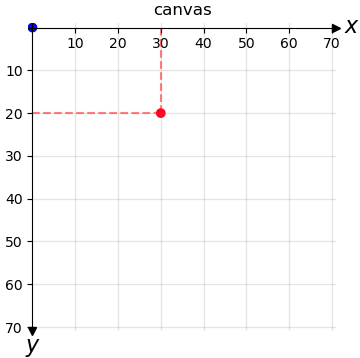

You locate positions on the screen by using pairs of numbers called **coordinates**. The first one is often referred to as the $x$ coordinate and it measures the horizontal distance from the left of the canvas. The second is often called the $y$ coordinate and it measures the vertical distance from the top of the canvas. The top left corner of the canvas has coordinates $(0, 0)$ and is called the *origin*. The red point in the image above has coordinates $(30, 20)$, 30 units from the left and 20 units from the top.

Let's do the following:
- create a canvas with size 400x400 pixels
- fill it with a red background
- draw a white square at the center of the canvas
- show the result

The code to do this is:

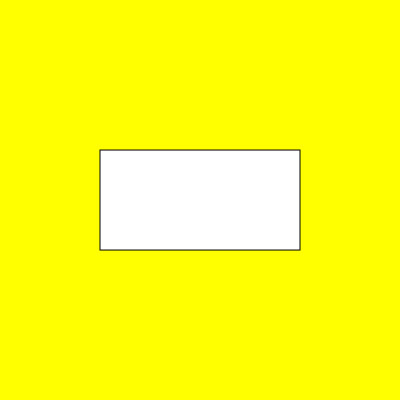

In [12]:
create_canvas(400, 400) # or equivalently create_canvas(400, 400)
background(255, 255, 0)
rect(200-100, 200-50, 200, 100)
show()

Let's go over the code line by line:

- The first line is pretty much self explanatory. The `create_canvas` (or equivalently `size`) function creates a canvas of a given horizontal and vertical size (in pixels). It takes two arguments separated by commas, which determine the desired size in pixels. 
- The second line fills the background with a given color, expressed with three values: The amount of red, the amount of blue and the amount of green. By default, these values have a range between 0 (min) and 255 (max). 
- The third line creates a rectangle. The rectangle is defined with two numbers determining the coordinates of the top left corner of the rectangle, followed by two numbers defining the width and height (a total of 4 numbers). The top-left corner has a $x$ coordinate of `200-50` pixels (distance from the left of the canvas), and a $y$ coordinate of `200-50` pixels (distance from the top). The rectangle is `100` pixels wide and `100` pixels high. 
- The fourth line shows the canvas under the current code cell.

The rectangle is white with a black outline because that is the default color that any shape uses when a canvas is initialized. 
The canvas is persistent across the notebook until `create_canvas` is used again. For example we can show the same canvas again by doing:

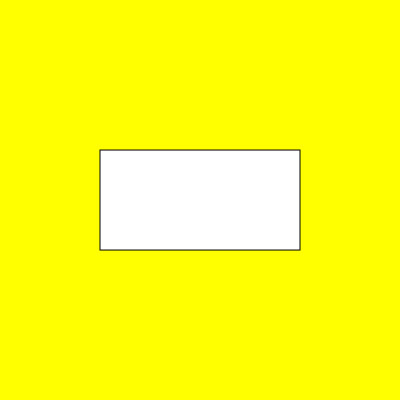

In [14]:
show()

Specifying a centered rectangle in the way we did above can be a bit awkward, since we need to adjust the top left coordinate based on the size. To simplify things we can set the "rect mode" and tell py5canvas that we want to specify the center rather than the corner. We can do this with the `rect_mode` function and specify `CENTER` as its argument (the default is `CORNER`). We will also fill the rectangle with another color, say a light blue, and without an outline, and then draw a black line that goes from one corner of the canvas to an opposite corner:

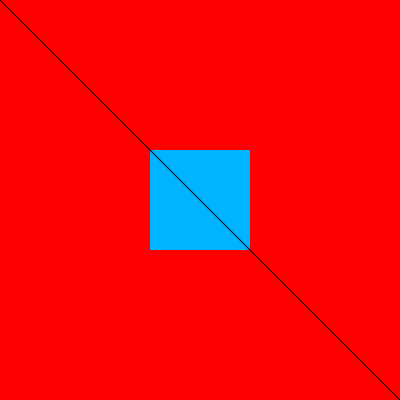

In [16]:
create_canvas(400, 400) # or equivalently create_canvas(400, 400)
background(255, 0, 0)
rect_mode(CENTER) # Draw rects from the center
fill(0, 180, 255)
no_stroke()
rect((width/2, height/2), 100, 100)
stroke(0)
line((0, 0), (width, height))
show()

First note that we used a slightly different syntax for the `line(...)` and `rect` functions as they use coordinates delimited by parentheses. Both this and the previous example are valid combinations of parameters for the functions, and it is up to you to decide what you prefer. The Py5canvas syntax is designed to allow different possibilities in order to facilitate conversion of scripts written in different flavors of Processing (e.g Processing, P5js or p5py).

In the example above, we also modify the fill and stroke colors using the `fill(...)`, `no_stroke()` and `stroke()` functions. 

The `fill(...)` function is similar to `background(...)`, it takes a color as an argument expressed as a triplet of numbers indicating the amount of red, the amount of green and the amount of blue (R, G, B) that are added together to create a color. White is created by adding together a full amount of the three components, e.g. `fill(255, 255, 255)`. With grayscale colors it is sufficient to specify a single value, so a white fill can be expressed also as `fill(255)`. Refer to [this Py5canvas version of a tutorial by Daniel Shiffman](./noc_color.ipynb) for a more in depth explanation of colors.

The `stroke(...)` function works identically, but it sets the stroke color rather than the fill. The `no_stroke()` function disables the stroke, and you can similarly disable the fill with `no_fill()`.

Note that the code is "stateful", that is we set a state (e.g. the current fill color) and that state persists to the following drawing commands. The `no_stroke()` disables the outline for the rectangle. As a result we use `stroke(0)` to set it back to black in order to draw the diagonal line.

Try experimenting with additional drawing functions, such as 
- `circle(center_x, center_y, radius)` that draws a circle given three arguments
- `ellipse(center_x, center_y, width, height)` that draws an ellipse given its center coordinates, width and height (4 arguments)
- `quad(x1, y1, x2, y2, x3, y3, x4, y4)` that draws a polygon with four vertices defined by a sequence of 8 arguments, one for each coordinate.

You can find a list of all functionality in the canvas API [here](https://github.com/colormotor/py5canvas/blob/main/docs).

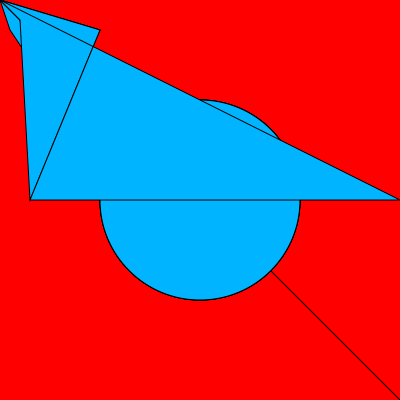

In [22]:
circle((width/2, height/2), 200)
quad(0,0, 400,200, 30,200, 100,30)